# Упражнения <a id='tasks'></a>

Необходимо изучить библиотеку [tslearn](https://tslearn.readthedocs.io/en/stable/).

1. Взять выбранные для лабы 14 набор(ы) данных. 

3. Попробовать все методы классификации и регрессии, описанные в блоноте 14 aeon:
    На основе расстояний 
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Глубокое обучение

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [1]:
# Лабораторная 16: модели tslearn на тех же данных, что и в лабораторной 14
import os
os.environ.setdefault('KERAS_BACKEND', 'torch')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeon.datasets import load_from_ts_file

from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.neighbors import KNeighborsTimeSeriesClassifier, KNeighborsTimeSeriesRegressor
from tslearn.piecewise import PiecewiseAggregateApproximation, SymbolicAggregateApproximation

from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

import keras
from keras import layers

In [2]:
# Загрузка данных и предобработка

def to_3d(X):
    X = np.asarray(X, dtype=np.float32)
    return X[..., None]  # (n, T) -> (n, T, 1), добавляем размерность канала, добавляем размерность канала, добавляем размерность канала


def encode_labels(y_train, y_test):
    classes = sorted(np.unique(y_train).tolist())
    mapping = {c: i for i, c in enumerate(classes)}
    y_train_i = np.array([mapping[v] for v in y_train], dtype=np.int64)
    y_test_i = np.array([mapping[v] for v in y_test], dtype=np.int64)
    return y_train_i, y_test_i, classes


# Те же наборы данных, что и в лабораторной 14
X_train_c, y_train_c = load_from_ts_file('./dataset/KDD_UTSC_TRAIN.ts', return_type='numpy2D')
X_test_c, y_test_c = load_from_ts_file('./dataset/KDD_UTSC_TEST.ts', return_type='numpy2D')

X_train_r, y_train_r = load_from_ts_file('./dataset/KDD_UTSER_TRAIN.ts', return_type='numpy2D')
X_test_r, y_test_r = load_from_ts_file('./dataset/KDD_UTSER_TEST.ts', return_type='numpy2D')

Xtr_c, Xte_c = to_3d(X_train_c), to_3d(X_test_c)
Xtr_r, Xte_r = to_3d(X_train_r), to_3d(X_test_r)

# Масштабирование по каждому временному ряду
scaler_c = TimeSeriesScalerMeanVariance()
Xtr_c = scaler_c.fit_transform(Xtr_c)
Xte_c = scaler_c.transform(Xte_c)

scaler_r = TimeSeriesScalerMeanVariance()
Xtr_r = scaler_r.fit_transform(Xtr_r)
Xte_r = scaler_r.transform(Xte_r)

yc_tr, yc_te, classes = encode_labels(y_train_c, y_test_c)

print('Classification:', Xtr_c.shape, Xte_c.shape, 'classes=', classes)
print('Regression:', Xtr_r.shape, Xte_r.shape, 'y range=', (float(np.min(y_train_r)), float(np.max(y_train_r))))

Classification: (40, 100, 1) (40, 100, 1) classes= ['rest', 'task']
Regression: (72, 100, 1) (72, 100, 1) y range= (0.602059991328, 4.695394108291)


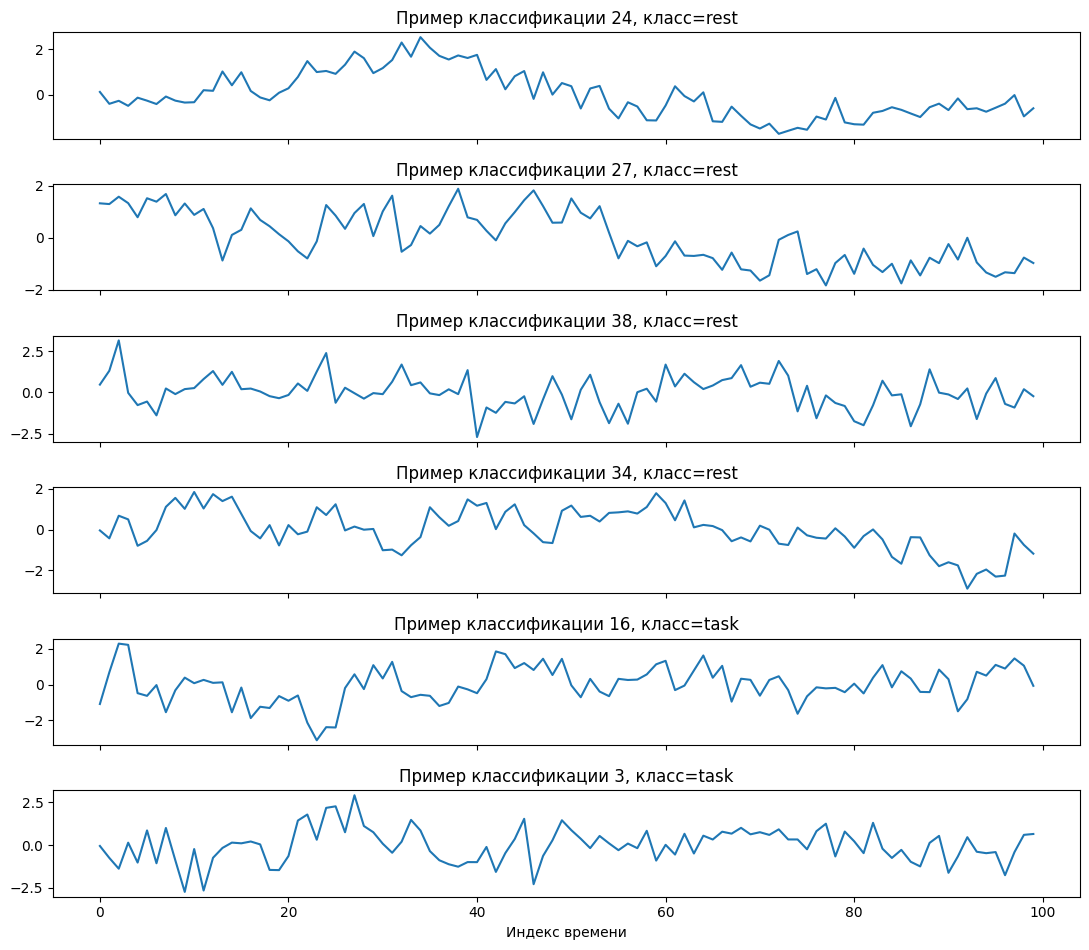

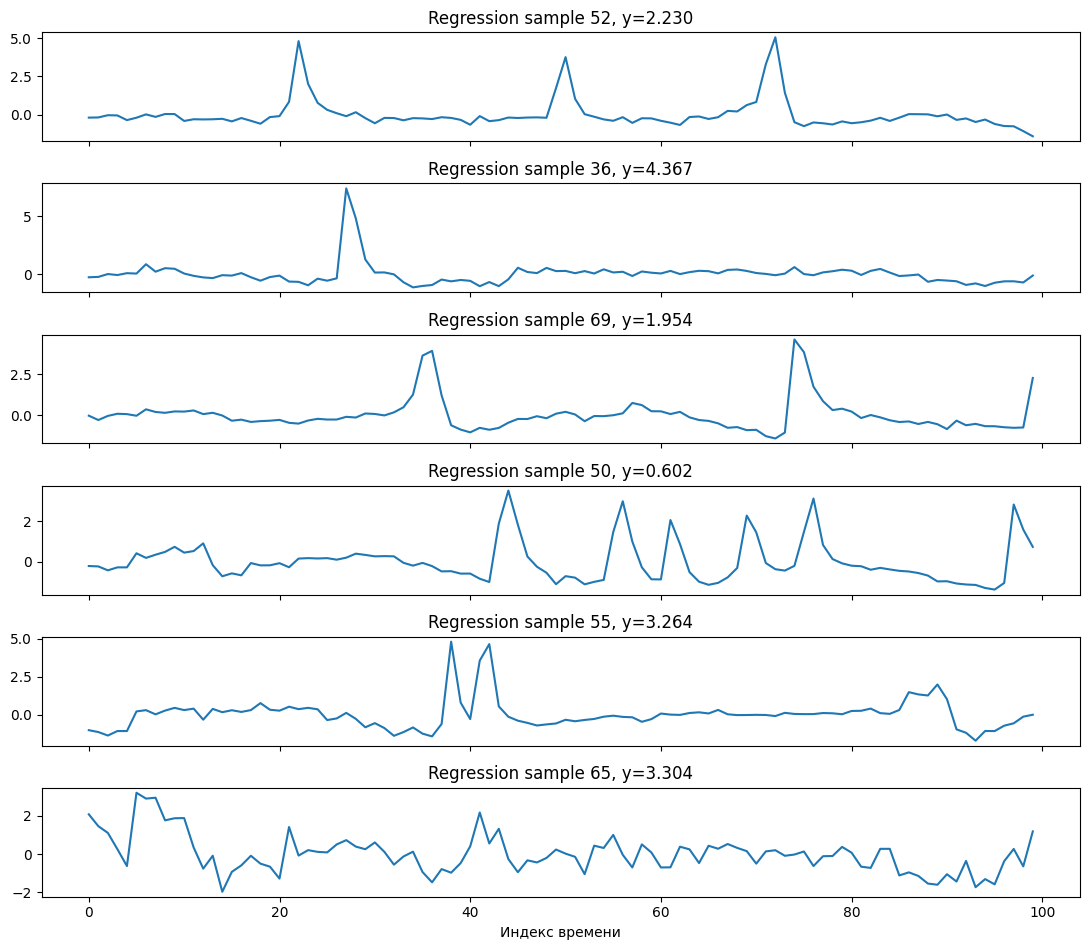

In [3]:
# Визуализация данных (шаг 2 упражнения)
rng = np.random.default_rng(42)

idx_c = rng.choice(len(Xtr_c), size=min(6, len(Xtr_c)), replace=False)
fig, axes = plt.subplots(len(idx_c), 1, figsize=(11, 1.6 * len(idx_c)), sharex=True)
if len(idx_c) == 1:
    axes = [axes]
for ax, i in zip(axes, idx_c):
    ax.plot(Xtr_c[i, :, 0])
    ax.set_title(f'Пример классификации {i}, класс={y_train_c[i]}')
ax.set_xlabel('Индекс времени')
plt.tight_layout()
plt.show()

idx_r = rng.choice(len(Xtr_r), size=min(6, len(Xtr_r)), replace=False)
fig, axes = plt.subplots(len(idx_r), 1, figsize=(11, 1.6 * len(idx_r)), sharex=True)
if len(idx_r) == 1:
    axes = [axes]
for ax, i in zip(axes, idx_r):
    ax.plot(Xtr_r[i, :, 0])
    ax.set_title(f'Regression sample {i}, y={y_train_r[i]:.3f}')
ax.set_xlabel('Индекс времени')
plt.tight_layout()
plt.show()

In [4]:
# Общие вспомогательные функции оценки

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), 1e-9)
    return float(np.mean(np.abs((y_true - y_pred) / denom)))


results = []


def push_cls(approach, model_name, y_true, y_pred):
    results.append({
        'task': 'classification',
        'approach': approach,
        'model': model_name,
        'metric': 'accuracy',
        'value': float(accuracy_score(y_true, y_pred)),
    })


def push_reg(approach, model_name, y_true, y_pred):
    results.extend([
        {'task': 'regression', 'approach': approach, 'model': model_name, 'metric': 'mse', 'value': float(mean_squared_error(y_true, y_pred))},
        {'task': 'regression', 'approach': approach, 'model': model_name, 'metric': 'mae', 'value': float(mean_absolute_error(y_true, y_pred))},
        {'task': 'regression', 'approach': approach, 'model': model_name, 'metric': 'mape', 'value': float(mape(y_true, y_pred))},
    ])

In [5]:
# 1) Подход на основе расстояний: минимум 3 модели для классификации и минимум 3 модели для регрессии
for metric in ['euclidean', 'dtw', 'softdtw']:
    params = {'gamma': 0.1} if metric == 'softdtw' else None

    clf = KNeighborsTimeSeriesClassifier(n_neighbors=1, metric=metric, metric_params=params)
    clf.fit(Xtr_c, yc_tr)
    pred = clf.predict(Xte_c)
    push_cls('distance', f'KNN({metric})', yc_te, pred)

    rgs = KNeighborsTimeSeriesRegressor(n_neighbors=1, metric=metric, metric_params=params)
    rgs.fit(Xtr_r, y_train_r)
    pred = rgs.predict(Xte_r)
    push_reg('distance', f'KNN({metric})', y_test_r, pred)

In [6]:
# 2) Подход на основе признаков: минимум 3 модели для классификации и регрессии
flatten = FunctionTransformer(lambda X: X.reshape(X.shape[0], -1), validate=False)

# Модели классификации
clf_feature_models = [
    ('PAA(10)+LogReg', make_pipeline(PiecewiseAggregateApproximation(n_segments=10), flatten, StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))),
    ('PAA(20)+RF', make_pipeline(PiecewiseAggregateApproximation(n_segments=20), flatten, RandomForestClassifier(n_estimators=300, random_state=42))),
    ('SAX(12,6)+LogReg', make_pipeline(SymbolicAggregateApproximation(n_segments=12, alphabet_size_avg=6), flatten, StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))),
]

for name, model in clf_feature_models:
    model.fit(Xtr_c, yc_tr)
    pred = model.predict(Xte_c)
    push_cls('feature', name, yc_te, pred)

# Модели регрессии
reg_feature_models = [
    ('PAA(10)+Ridge', make_pipeline(PiecewiseAggregateApproximation(n_segments=10), flatten, StandardScaler(), Ridge(alpha=1.0))),
    ('PAA(20)+RFReg', make_pipeline(PiecewiseAggregateApproximation(n_segments=20), flatten, RandomForestRegressor(n_estimators=300, random_state=42))),
    ('SAX(12,6)+Ridge', make_pipeline(SymbolicAggregateApproximation(n_segments=12, alphabet_size_avg=6), flatten, StandardScaler(), Ridge(alpha=1.0))),
]

for name, model in reg_feature_models:
    model.fit(Xtr_r, y_train_r)
    pred = model.predict(Xte_r)
    push_reg('feature', name, y_test_r, pred)

In [7]:
# Конструкторы Keras-моделей для сверточного подхода и подхода глубокого обучения

def build_model(kind, n_time, n_classes=None):
    inp = keras.Input(shape=(n_time, 1))

    if kind == 'mlp':
        x = layers.Flatten()(inp)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dense(64, activation='relu')(x)
    elif kind == 'gru':
        x = layers.GRU(32)(inp)
    elif kind == 'lstm':
        x = layers.LSTM(32)(inp)
    elif kind == 'cnn_small':
        x = layers.Conv1D(16, 5, padding='same', activation='relu')(inp)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(32, 5, padding='same', activation='relu')(x)
        x = layers.GlobalAveragePooling1D()(x)
    elif kind == 'cnn_fcn':
        x = layers.Conv1D(32, 8, padding='same', activation='relu')(inp)
        x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
        x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
        x = layers.GlobalAveragePooling1D()(x)
    elif kind == 'cnn_dilated':
        x = layers.Conv1D(16, 3, padding='causal', dilation_rate=1, activation='relu')(inp)
        x = layers.Conv1D(16, 3, padding='causal', dilation_rate=2, activation='relu')(x)
        x = layers.Conv1D(16, 3, padding='causal', dilation_rate=4, activation='relu')(x)
        x = layers.GlobalAveragePooling1D()(x)
    else:
        raise ValueError(f'Unknown model kind: {kind}')

    if n_classes is None:
        out = layers.Dense(1)(x)
        model = keras.Model(inp, out)
        model.compile(optimizer='adam', loss='mse')
    else:
        out = layers.Dense(n_classes, activation='softmax')(x)
        model = keras.Model(inp, out)
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model


def fit_predict_classification(kind, model_name, approach, epochs=30):
    model = build_model(kind, Xtr_c.shape[1], n_classes=len(classes))
    model.fit(Xtr_c, yc_tr, epochs=epochs, batch_size=16, verbose=0)
    pred = model.predict(Xte_c, verbose=0).argmax(axis=1)
    push_cls(approach, model_name, yc_te, pred)


def fit_predict_regression(kind, model_name, approach, epochs=40):
    model = build_model(kind, Xtr_r.shape[1], n_classes=None)
    model.fit(Xtr_r, y_train_r.astype(np.float32), epochs=epochs, batch_size=16, verbose=0)
    pred = model.predict(Xte_r, verbose=0).reshape(-1)
    push_reg(approach, model_name, y_test_r, pred)

In [8]:
# 3) Сверточный подход: минимум 3 модели для классификации и регрессии
conv_kinds = [
    ('cnn_small', 'Conv CNN-small'),
    ('cnn_fcn', 'Conv FCN-like'),
    ('cnn_dilated', 'Conv DilatedCNN'),
]

for kind, name in conv_kinds:
    fit_predict_classification(kind, name, approach='convolution', epochs=30)
    fit_predict_regression(kind, name, approach='convolution', epochs=40)

print('Сверточные модели обучены.')

Сверточные модели обучены.


In [9]:
# 4) Подход глубокого обучения: минимум 3 модели для классификации и минимум 3 модели для регрессии
deep_kinds = [
    ('mlp', 'Deep MLP'),
    ('gru', 'Deep GRU'),
    ('lstm', 'Deep LSTM'),
]

for kind, name in deep_kinds:
    fit_predict_classification(kind, name, approach='deep', epochs=30)
    fit_predict_regression(kind, name, approach='deep', epochs=40)

print('Deep-learning модели обучены.')

Deep-learning модели обучены.


In [10]:
# Итоговая таблица сравнения
results_df = pd.DataFrame(results)

display(results_df.sort_values(['task', 'approach', 'metric', 'value'], ascending=[True, True, True, False]))

summary = (
    results_df
    .groupby(['task', 'approach', 'metric'])['value']
    .agg(['max', 'mean'])
    .reset_index()
)
print('Лучшая/средняя метрика по подходам:')
display(summary.round(4))

,task,approach,model,metric,value
24,classification,convolution,Conv CNN-small,accuracy,0.800000
28,classification,convolution,Conv FCN-like,accuracy,0.725000
32,classification,convolution,Conv DilatedCNN,accuracy,0.550000
36,classification,deep,Deep MLP,accuracy,0.550000
40,classification,deep,Deep GRU,accuracy,0.525000
44,classification,deep,Deep LSTM,accuracy,0.525000
4,classification,distance,KNN(dtw),accuracy,0.575000
8,classification,distance,KNN(softdtw),accuracy,0.550000
0,classification,distance,KNN(euclidean),accuracy,0.525000
13,classification,feature,PAA(20)+RF,accuracy,0.500000


Лучшая/средняя метрика по подходам:


,task,approach,metric,max,mean
0,classification,convolution,accuracy,0.8000,0.6917
1,classification,deep,accuracy,0.5500,0.5333
2,classification,distance,accuracy,0.5750,0.5500
3,classification,feature,accuracy,0.5000,0.4917
4,regression,convolution,mae,0.9968,0.9741
5,regression,convolution,mape,0.6170,0.5992
6,regression,convolution,mse,1.4886,1.4087
7,regression,deep,mae,1.2342,1.0474
8,regression,deep,mape,0.6574,0.5864
9,regression,deep,mse,2.2241,1.6358


Краткие комментарии:

- Используются те же KDD-наборы, что и в лабораторной 14, для прямой сопоставимости результатов.
- В tslearn нативно покрыты distance- и feature-пайплайны, а сверточная и deep-learning части реализованы компактными моделями Keras (backend torch).
- Для каждого требуемого подхода реализовано минимум 3 модели классификации и минимум 3 модели регрессии.